# EMI Comparative Visual Analysis

This notebook compares unimodal (text/audio/video) predictions to the best fusion model and surfaces qualitative examples where a modality is wrong and the ensemble improves.

Notes:
- Set `MAX_SAMPLES` for quick runs.
- Video paths are derived as `DATA_DIR/videos/{id}.mp4`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoFeatureExtractor, WavLMModel
import matplotlib.pyplot as plt

# ===== Paths =====
DATA_DIR = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# text + audio + video inputs
TXT_DIR = DATA_DIR / "text_whisper_large_v3"
AUDIO_DIR = DATA_DIR / "audio"
EMI_FACE_DIR = DATA_DIR / "embeddings" / "faces_emotiefflib_enet_b0_8_best_afew_fps5_v1-repr"
VIDEO_DIR = DATA_DIR / "videos"

# model checkpoints
TEXT_CKPT = DATA_DIR / "runs" / "finetune_mgte_text_only_v1" / "best_by_val_pearson.pt"
AUDIO_CKPT = DATA_DIR / "runs" / "audio_wavlm_end2end_fps5_v1" / "best_by_val_pearson.pt"
VIDEO_CKPT = DATA_DIR / "runs" / "abaw8_emi_face_repro" / "best_by_corr.pt"

FUSION_RUN_DIR = DATA_DIR / "runs" / "multimodal_fusion_emi_face_v1"

MODEL_LIBRARY = DATA_DIR / "model_library"
ANALYSIS_DIR = MODEL_LIBRARY / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# ===== Task =====
EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
E = len(EMOTIONS)
ID_WIDTH = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ===== Selection settings =====
MAX_SAMPLES = None  # set to e.g. 300 for quick run
TAU = 0.20          # modality MAE threshold
DELTA = 0.05        # fusion improvement margin


In [2]:
# ===== Helpers =====

def video_path(vid: str) -> Path:
    return VIDEO_DIR / f"{vid}.mp4"

def mae(y_pred, y_true):
    return np.mean(np.abs(y_pred - y_true))

def safe_argmax(x):
    return int(np.argmax(x)) if x is not None else None


In [3]:
# ===== Text model =====
MODEL_ID = "Alibaba-NLP/gte-base-en-v1.5"
MAX_LEN = 128
L2_NORM_CLS = False

class mGTERegressor(nn.Module):
    def __init__(self, model_id: str, num_targets: int, hidden: int = 512, dropout: float = 0.2, l2_norm_cls: bool = False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_id, trust_remote_code=True)
        self.l2_norm_cls = l2_norm_cls
        d = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_targets)
        )
    def forward(self, tok):
        out = self.encoder(**tok)
        cls = out.last_hidden_state[:, 0, :]
        if self.l2_norm_cls:
            cls = F.normalize(cls, p=2, dim=1)
        return self.head(cls)


In [4]:
# ===== Audio model =====
TARGET_SR = 16_000
AUDIO_MAX_SEC = 20.0
CROP_MODE = "first"
TARGET_FPS = 5
HOP_SEC = 1.0 / TARGET_FPS
NUM_BINS = int(np.ceil(AUDIO_MAX_SEC / HOP_SEC))
MODEL_NAME = "microsoft/wavlm-large"

class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])
    def forward(self, x):
        x = x.transpose(1, 2)
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )
    def forward(self, x, mask):
        logits = self.attn(x).squeeze(-1) / self.temp
        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)
        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

def hidden_to_fps_bins(hidden: torch.Tensor, input_lengths: torch.Tensor, output_lengths: torch.Tensor,
                       sr: int, hop_sec: float, num_bins: int):
    B, Lmax, H = hidden.shape
    device = hidden.device
    dur = input_lengths.float() / float(sr)
    x_out, m_out = [], []
    for b in range(B):
        Lb = int(output_lengths[b].item())
        if Lb <= 0:
            x_out.append(torch.zeros((num_bins, H), device=device, dtype=hidden.dtype))
            m_out.append(torch.zeros((num_bins,), device=device, dtype=torch.bool))
            continue
        hb = hidden[b, :Lb, :]
        stride = dur[b] / float(Lb)
        t = torch.arange(Lb, device=device, dtype=torch.float32) * stride
        idx = torch.floor(t / float(hop_sec)).long()
        valid = (idx >= 0) & (idx < num_bins)
        sums = torch.zeros((num_bins, H), device=device, dtype=hidden.dtype)
        cnts = torch.zeros((num_bins,), device=device, dtype=torch.int32)
        if valid.any():
            ii = idx[valid]
            sums.index_add_(0, ii, hb[valid])
            cnts.index_add_(0, ii, torch.ones_like(ii, dtype=torch.int32))
        xb = sums / cnts.clamp_min(1).unsqueeze(1).to(sums.dtype)
        mb = cnts > 0
        x_out.append(xb)
        m_out.append(mb)
    return torch.stack(x_out, dim=0), torch.stack(m_out, dim=0)

class AudioWavLMEnd2End(nn.Module):
    def __init__(self, encoder: WavLMModel, d_model: int = 192, tcn_layers: int = 6, tcn_kernel: int = 3,
                 dropout: float = 0.3, attn_hidden: int = 128):
        super().__init__()
        self.encoder = encoder
        h_in = int(encoder.config.hidden_size)
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.tcn = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = AttentiveStatsPooling(d_model, attn_hidden, dropout, temp=1.5)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, E),
        )
    def forward(self, fe):
        input_values = fe["input_values"]
        attention_mask = fe.get("attention_mask", None)
        if attention_mask is None:
            attention_mask = torch.ones_like(input_values, dtype=torch.long)
        input_lengths = attention_mask.sum(-1)
        output_lengths = self.encoder._get_feat_extract_output_lengths(input_lengths)
        out = self.encoder(input_values=input_values, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        x_bins, m_bins = hidden_to_fps_bins(hidden, input_lengths, output_lengths, TARGET_SR, HOP_SEC, NUM_BINS)
        x = self.proj(x_bins)
        x = self.tcn(x)
        z = self.pool(x, m_bins)
        return self.head(z)


In [5]:
# ===== Audio utils =====
import random

def load_audio_mono_16k(mp3_path: Path, target_sr: int = 16000):
    # returns wav [T] and sr
    try:
        import torchaudio
        wav, sr = torchaudio.load(str(mp3_path))  # [C, T]
        if wav.ndim == 2 and wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        wav = wav.squeeze(0)  # [T]

        if sr != target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
            wav = resampler(wav.unsqueeze(0)).squeeze(0)
            sr = target_sr
        return wav.contiguous().float(), sr

    except Exception:
        import librosa
        x, sr = librosa.load(str(mp3_path), sr=target_sr, mono=True)
        wav = torch.from_numpy(x).float()
        return wav.contiguous(), target_sr


def crop_wav(wav: torch.Tensor, sr: int, max_sec: float, mode: str = "first") -> torch.Tensor:
    if max_sec is None or max_sec <= 0:
        return wav
    max_samples = int(max_sec * sr)
    if wav.numel() <= max_samples:
        return wav
    if mode == "first":
        return wav[:max_samples]
    if mode == "random":
        start = random.randint(0, wav.numel() - max_samples)
        return wav[start:start + max_samples]
    raise ValueError(f"Unknown CROP_MODE={mode}")


In [6]:
# ===== Video (EMI face) model =====
class EmiFaceHead(nn.Module):
    def __init__(self, in_dim: int, num_targets: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_targets)
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

def load_emi_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)
    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), dtype=bool)
    return emb, valid

def pool_video_emi(emb: np.ndarray, valid: np.ndarray) -> np.ndarray:
    x = emb[valid]
    if x.shape[0] == 0:
        return np.zeros((emb.shape[1]*4,), dtype=np.float32)
    mu = x.mean(axis=0)
    std = x.std(axis=0)
    mn = x.min(axis=0)
    mx = x.max(axis=0)
    return np.concatenate([mu, std, mn, mx]).astype(np.float32)


In [7]:
# ===== Fusion models (from multimodal_fusion_emi_face_v1) =====
MODS = ["audio", "text", "video"]
M = len(MODS)

eps = 1e-4

class QualityAwareGatedFusion(nn.Module):
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(E + 2, hidden),
            nn.GELU(),
            nn.Linear(hidden, E),
        )
        self.bias = nn.Parameter(torch.zeros((E,), dtype=torch.float32))
    def forward(self, P: torch.Tensor, avail: torch.Tensor, quality: torch.Tensor):
        feat = torch.cat([P, quality.unsqueeze(-1), avail.unsqueeze(-1).float()], dim=-1)
        logits = self.mlp(feat)
        mask = avail.unsqueeze(-1).expand_as(logits)
        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        fused = (w * P).sum(dim=1) + self.bias
        return fused, w

class ModalityTokenTransformer(nn.Module):
    def __init__(self, d_model: int = 64, nhead: int = 4, layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Linear(E + 2, d_model)
        self.mod_emb = nn.Embedding(M, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=2*d_model, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, E),
        )
    def forward(self, P: torch.Tensor, avail: torch.Tensor, quality: torch.Tensor):
        feat = torch.cat([P, quality.unsqueeze(-1), avail.unsqueeze(-1).float()], dim=-1)
        tok = self.proj(feat)
        mod_ids = torch.arange(M, device=P.device)
        tok = tok + self.mod_emb(mod_ids)[None, :, :]
        pad_mask = ~avail
        z = self.enc(tok, src_key_padding_mask=pad_mask)
        w = avail.float().unsqueeze(-1)
        pooled = (z * w).sum(dim=1) / (w.sum(dim=1) + 1e-6)
        out = self.head(pooled)
        return out, z

class TemporalTokenTransformer(nn.Module):
    def __init__(self, d_model: int = 64, nhead: int = 4, layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Linear(E + 1, d_model)
        self.mod_emb = nn.Embedding(3, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=2*d_model, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, E),
        )
    def forward(self, Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt):
        ta = torch.cat([Pa, Qa.unsqueeze(-1)], dim=-1)
        tv = torch.cat([Pv, Qv.unsqueeze(-1)], dim=-1)
        tt = torch.cat([Pt, torch.ones_like(Mt, dtype=Pa.dtype).unsqueeze(-1)], dim=-1)
        tok_a = self.proj(ta) + self.mod_emb(torch.tensor([0], device=Pa.device))[None, :, :]
        tok_v = self.proj(tv) + self.mod_emb(torch.tensor([1], device=Pa.device))[None, :, :]
        tok_t = self.proj(tt) + self.mod_emb(torch.tensor([2], device=Pa.device))[None, :, :]
        tokens = torch.cat([tok_a, tok_v, tok_t], dim=1)
        mask = torch.cat([Ma, Mv, Mt], dim=1)
        z = self.enc(tokens, src_key_padding_mask=~mask)
        w = mask.float().unsqueeze(-1)
        pooled = (z * w).sum(dim=1) / (w.sum(dim=1) + 1e-6)
        out = self.head(pooled)
        return out, z


In [8]:
# ===== Load data =====
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

if MAX_SAMPLES is not None:
    valid_df = valid_df.head(MAX_SAMPLES)

ids = valid_df["Filename"].tolist()
y_true = valid_df[EMOTIONS].values.astype(np.float32)

# compute audio normalization from train split
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
y_train = train_df[EMOTIONS].values.astype(np.float32)
y_mean = y_train.mean(axis=0)
y_std = np.clip(y_train.std(axis=0), 1e-3, None)


In [9]:
# ===== Load models =====
# Text
text_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
text_model = mGTERegressor(MODEL_ID, E, hidden=512, dropout=0.2, l2_norm_cls=L2_NORM_CLS)
text_ckpt = torch.load(TEXT_CKPT, map_location="cpu")
text_model.load_state_dict(text_ckpt["model_state"])
text_model.to(DEVICE).eval()

# Audio
audio_encoder = WavLMModel.from_pretrained(MODEL_NAME)
audio_model = AudioWavLMEnd2End(audio_encoder).to(DEVICE)
audio_ckpt = torch.load(AUDIO_CKPT, map_location="cpu")
audio_model.load_state_dict(audio_ckpt["model_state"])
audio_model.eval()
audio_fe = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

# Video (EMI)
# input dim is 5120 (4 * 1280)
emi_model = EmiFaceHead(5120, E)
video_ckpt = torch.load(VIDEO_CKPT, map_location="cpu")
emi_model.load_state_dict(video_ckpt["model_state"])
emi_model.to(DEVICE).eval()


EmiFaceHead(
  (fc): Linear(in_features=5120, out_features=6, bias=True)
)

In [10]:
# ===== Compute predictions (with caching) =====
text_cache = ANALYSIS_DIR / "pred_text.npz"
audio_cache = ANALYSIS_DIR / "pred_audio.npz"
video_cache = ANALYSIS_DIR / "pred_video.npz"

# ---- Text ----
if text_cache.exists():
    d = np.load(text_cache, allow_pickle=False)
    P_text = d["P"]
    A_text = d["A"]
else:
    P_text = np.full((len(ids), E), np.nan, np.float32)
    A_text = np.zeros((len(ids),), dtype=bool)
    batch = []
    batch_ids = []
    for i, vid in enumerate(tqdm(ids, desc="Text preds")):
        p = TXT_DIR / f"{vid}.txt"
        if not p.exists():
            continue
        t = p.read_text(encoding="utf-8").strip()
        if not t:
            t = "[NO SPEECH]"
        batch.append(t)
        batch_ids.append(i)
        if len(batch) >= 32:
            tok = text_tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
            tok = {k: v.to(DEVICE, non_blocking=True) for k, v in tok.items()}
            with torch.no_grad():
                pred = text_model(tok).detach().cpu().numpy()
            for j, idx in enumerate(batch_ids):
                P_text[idx] = pred[j]
                A_text[idx] = True
            batch, batch_ids = [], []
    if batch:
        tok = text_tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
        tok = {k: v.to(DEVICE, non_blocking=True) for k, v in tok.items()}
        with torch.no_grad():
            pred = text_model(tok).detach().cpu().numpy()
        for j, idx in enumerate(batch_ids):
            P_text[idx] = pred[j]
            A_text[idx] = True
    np.savez_compressed(text_cache, P=P_text, A=A_text)

# ---- Audio ----
if audio_cache.exists():
    d = np.load(audio_cache, allow_pickle=False)
    P_audio = d["P"]
    A_audio = d["A"]
else:
    P_audio = np.full((len(ids), E), np.nan, np.float32)
    A_audio = np.zeros((len(ids),), dtype=bool)
    for i, vid in enumerate(tqdm(ids, desc="Audio preds")):
        p = AUDIO_DIR / f"{vid}.mp3"
        if not p.exists():
            continue
        wav, sr = load_audio_mono_16k(p, TARGET_SR)
        wav = crop_wav(wav, sr, AUDIO_MAX_SEC, CROP_MODE)
        fe = audio_fe(wav, sampling_rate=TARGET_SR, return_tensors="pt")
        fe = {k: v.to(DEVICE, non_blocking=True) for k, v in fe.items()}
        with torch.no_grad():
            pred_norm = audio_model(fe).detach().cpu().numpy()[0]
        pred = pred_norm * y_std + y_mean
        P_audio[i] = pred
        A_audio[i] = True
    np.savez_compressed(audio_cache, P=P_audio, A=A_audio)

# ---- Video (EMI face) ----
if video_cache.exists():
    d = np.load(video_cache, allow_pickle=False)
    P_video = d["P"]
    A_video = d["A"]
else:
    P_video = np.full((len(ids), E), np.nan, np.float32)
    A_video = np.zeros((len(ids),), dtype=bool)
    for i, vid in enumerate(tqdm(ids, desc="Video preds (EMI face)")):
        p = EMI_FACE_DIR / f"{vid}.npz"
        if not p.exists():
            continue
        emb, valid = load_emi_face_npz(p)
        if valid.sum() < 5:
            continue
        feat = pool_video_emi(emb, valid)
        xt = torch.from_numpy(feat).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = emi_model(xt).detach().cpu().numpy()[0]
        P_video[i] = pred
        A_video[i] = True
    np.savez_compressed(video_cache, P=P_video, A=A_video)


In [11]:
# ===== Fusion predictions =====
# choose best method from history
best_method = None
best_corr = -1e9
for m in ["quality_gated", "modality_transformer", "temporal_xattn"]:
    hist_path = FUSION_RUN_DIR / m / "history.json"
    if not hist_path.exists():
        continue
    hist = json.loads(hist_path.read_text())
    if not hist.get("val_corr"):
        continue
    c = max(hist["val_corr"])
    if c > best_corr:
        best_corr = c
        best_method = m

assert best_method is not None, "No fusion history found"

# build model
if best_method == "quality_gated":
    fusion_model = QualityAwareGatedFusion(hidden=32).to(DEVICE)
    static_mode = True
elif best_method == "modality_transformer":
    fusion_model = ModalityTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
    static_mode = True
else:
    fusion_model = TemporalTokenTransformer(d_model=64, nhead=4, layers=2, dropout=0.1).to(DEVICE)
    static_mode = False

ckpt_path = FUSION_RUN_DIR / best_method / "best_fusion.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
fusion_model.load_state_dict(ckpt["model_state"])
fusion_model.eval()

# build inputs from unimodal predictions
P = np.stack([
    np.nan_to_num(P_audio, nan=0.0),
    np.nan_to_num(P_text, nan=0.0),
    np.nan_to_num(P_video, nan=0.0)
], axis=1)  # [N,3,E]
A = np.stack([A_audio, A_text, A_video], axis=1)  # [N,3]
Q = A.astype(np.float32)  # simple quality proxy

P_fusion = np.full((len(ids), E), np.nan, np.float32)

if static_mode:
    xb = torch.from_numpy(P).float().to(DEVICE)
    ab = torch.from_numpy(A).bool().to(DEVICE)
    qb = torch.from_numpy(Q).float().to(DEVICE)
    with torch.no_grad():
        out, _ = fusion_model(xb, ab, qb)
    P_fusion = out.detach().cpu().numpy()
else:
    # temporal: use length-1 sequences built from per-modality preds
    Pa = torch.from_numpy(P[:,0:1,:]).float().to(DEVICE)
    Ma = torch.from_numpy(A[:,0:1]).bool().to(DEVICE)
    Qa = torch.from_numpy(Q[:,0:1]).float().to(DEVICE)
    Pv = torch.from_numpy(P[:,2:3,:]).float().to(DEVICE)
    Mv = torch.from_numpy(A[:,2:3]).bool().to(DEVICE)
    Qv = torch.from_numpy(Q[:,2:3]).float().to(DEVICE)
    Pt = torch.from_numpy(P[:,1:2,:]).float().to(DEVICE)
    Mt = torch.from_numpy(A[:,1:2]).bool().to(DEVICE)
    with torch.no_grad():
        out, _ = fusion_model(Pa, Ma, Qa, Pv, Mv, Qv, Pt, Mt)
    P_fusion = out.detach().cpu().numpy()


In [12]:
# ===== Build analysis table =====
rows = []
for i, vid in enumerate(ids):
    row = {"video_id": vid, "video_path": str(video_path(vid))}
    yt = y_true[i]
    row.update({f"y_true_{e}": float(yt[j]) for j, e in enumerate(EMOTIONS)})

    preds = {
        "text": P_text[i] if A_text[i] else None,
        "audio": P_audio[i] if A_audio[i] else None,
        "video": P_video[i] if A_video[i] else None,
        "fusion": P_fusion[i],
    }

    for k, p in preds.items():
        if p is None or np.isnan(p).any():
            row[f"mae_{k}"] = np.nan
            row[f"argmax_{k}"] = np.nan
        else:
            row[f"mae_{k}"] = float(mae(p, yt))
            row[f"argmax_{k}"] = int(np.argmax(p))

    row["argmax_true"] = int(np.argmax(yt))
    rows.append(row)

df = pd.DataFrame(rows)

# selection: MAE improvement
cands = []
for mod in ["text", "audio", "video"]:
    cond = (
        (df[f"mae_{mod}"] > TAU) &
        (df["mae_fusion"] + DELTA < df[f"mae_{mod}"])
    )
    cands.append(df[cond])

cand_mae = pd.concat(cands).drop_duplicates(subset=["video_id"]) if cands else df.head(0)

# selection: argmax mismatch
cand_arg = df[
    (df["argmax_fusion"] == df["argmax_true"]) &
    (
        (df["argmax_text"] != df["argmax_true"]) |
        (df["argmax_audio"] != df["argmax_true"]) |
        (df["argmax_video"] != df["argmax_true"])
    )
]

cand_all = pd.concat([cand_mae, cand_arg]).drop_duplicates(subset=["video_id"])

cand_all.to_csv(ANALYSIS_DIR / "analysis_candidates.csv", index=False)
print("Candidates saved to", ANALYSIS_DIR / "analysis_candidates.csv")

cand_all.head(10)


Candidates saved to /home/danila/networks/data/model_library/analysis/analysis_candidates.csv


,video_id,video_path,y_true_Admiration,y_true_Amusement,y_true_Determination,y_true_Empathic Pain,y_true_Excitement,y_true_Joy,mae_text,argmax_text,mae_audio,argmax_audio,mae_video,argmax_video,mae_fusion,argmax_fusion,argmax_true
258,08330,/home/danila/networks/data/videos/08330.mp4,0.666667,0.000000,0.333333,0.333333,0.000000,0.000000,0.322578,4,0.217250,2,0.330218,0.0,0.215547,4,0
328,08400,/home/danila/networks/data/videos/08400.mp4,0.333333,0.333333,0.000000,0.000000,0.333333,1.000000,0.389867,2,0.274398,4,0.332129,5.0,0.249860,4,5
498,08570,/home/danila/networks/data/videos/08570.mp4,0.000000,0.333333,0.000000,0.000000,0.333333,0.333333,0.200048,0,0.097017,1,0.460572,4.0,0.115020,1,1
840,08912,/home/danila/networks/data/videos/08912.mp4,0.500000,0.500000,0.500000,0.000000,1.000000,0.500000,0.416841,4,0.309005,4,0.214355,0.0,0.328128,4,4
1005,09077,/home/danila/networks/data/videos/09077.mp4,0.500000,0.000000,0.000000,0.500000,0.000000,0.000000,0.256335,5,0.057589,3,0.343734,0.0,0.174128,3,0
1052,09124,/home/danila/networks/data/videos/09124.mp4,0.200000,0.400000,0.000000,0.000000,0.600000,0.800000,0.311503,1,0.210154,1,0.284266,4.0,0.258542,1,5
1896,09968,/home/danila/networks/data/videos/09968.mp4,0.000000,0.333333,0.000000,0.000000,0.333333,0.333333,0.239560,0,0.080002,1,0.420906,4.0,0.142858,0,1
2098,10170,/home/danila/networks/data/videos/10170.mp4,0.000000,0.333333,0.000000,0.000000,0.333333,1.000000,0.272832,1,0.182266,4,0.384209,5.0,0.194794,4,5
2223,10295,/home/danila/networks/data/videos/10295.mp4,0.000000,0.500000,0.000000,0.000000,0.500000,0.500000,0.240832,0,0.203129,5,0.362218,5.0,0.173479,5,1
2385,10457,/home/danila/networks/data/videos/10457.mp4,0.000000,0.000000,0.000000,0.333333,0.666667,0.666667,0.270529,4,0.176867,4,0.307944,4.0,0.200149,4,4


In [13]:
# ===== Modality-specific illustrative examples =====
# text wrong, fusion correct
text_wrong = df[
    (df["argmax_text"].notna()) &
    (df["argmax_fusion"] == df["argmax_true"]) &
    (df["argmax_text"] != df["argmax_true"])
].copy()

# audio wrong, fusion correct
audio_wrong = df[
    (df["argmax_audio"].notna()) &
    (df["argmax_fusion"] == df["argmax_true"]) &
    (df["argmax_audio"] != df["argmax_true"])
].copy()

# video wrong, fusion correct
video_wrong = df[
    (df["argmax_video"].notna()) &
    (df["argmax_fusion"] == df["argmax_true"]) &
    (df["argmax_video"] != df["argmax_true"])
].copy()

# rank by improvement in MAE (modality -> fusion)
text_wrong["delta_mae"] = text_wrong["mae_text"] - text_wrong["mae_fusion"]
audio_wrong["delta_mae"] = audio_wrong["mae_audio"] - audio_wrong["mae_fusion"]
video_wrong["delta_mae"] = video_wrong["mae_video"] - video_wrong["mae_fusion"]

text_wrong = text_wrong.sort_values("delta_mae", ascending=False)
audio_wrong = audio_wrong.sort_values("delta_mae", ascending=False)
video_wrong = video_wrong.sort_values("delta_mae", ascending=False)

# save top candidates
text_wrong.head(50).to_csv(ANALYSIS_DIR / "text_wrong_fusion_correct.csv", index=False)
audio_wrong.head(50).to_csv(ANALYSIS_DIR / "audio_wrong_fusion_correct.csv", index=False)
video_wrong.head(50).to_csv(ANALYSIS_DIR / "video_wrong_fusion_correct.csv", index=False)

print("Top text-wrong examples saved to", ANALYSIS_DIR / "text_wrong_fusion_correct.csv")
print("Top audio-wrong examples saved to", ANALYSIS_DIR / "audio_wrong_fusion_correct.csv")
print("Top video-wrong examples saved to", ANALYSIS_DIR / "video_wrong_fusion_correct.csv")

text_wrong.head(10)


Top text-wrong examples saved to /home/danila/networks/data/model_library/analysis/text_wrong_fusion_correct.csv
Top audio-wrong examples saved to /home/danila/networks/data/model_library/analysis/audio_wrong_fusion_correct.csv
Top video-wrong examples saved to /home/danila/networks/data/model_library/analysis/video_wrong_fusion_correct.csv


,video_id,video_path,y_true_Admiration,y_true_Amusement,y_true_Determination,y_true_Empathic Pain,y_true_Excitement,y_true_Joy,mae_text,argmax_text,mae_audio,argmax_audio,mae_video,argmax_video,mae_fusion,argmax_fusion,argmax_true,delta_mae
498,08570,/home/danila/networks/data/videos/08570.mp4,0.000000,0.333333,0.000000,0.000000,0.333333,0.333333,0.200048,0,0.097017,1,0.460572,4.0,0.115020,1,1,0.085028
4229,12301,/home/danila/networks/data/videos/12301.mp4,0.000000,0.500000,0.000000,0.000000,1.000000,0.500000,0.329023,5,0.248124,4,0.335855,5.0,0.263631,4,4,0.065392
2116,10188,/home/danila/networks/data/videos/10188.mp4,0.333333,0.000000,0.166667,0.166667,0.000000,0.000000,0.171058,5,0.078263,0,NaN,NaN,0.110821,0,0,0.060237
1800,09872,/home/danila/networks/data/videos/09872.mp4,0.333333,0.333333,0.000000,0.000000,0.666667,0.333333,0.214410,0,0.195337,5,0.297054,0.0,0.175153,4,4,0.039257
1701,09773,/home/danila/networks/data/videos/09773.mp4,0.000000,0.333333,0.000000,0.000000,0.666667,0.333333,0.213054,0,0.163415,5,0.366250,4.0,0.177548,4,4,0.035506
4235,12307,/home/danila/networks/data/videos/12307.mp4,0.333333,0.333333,0.000000,0.000000,0.666667,0.000000,0.222757,5,0.119600,4,0.377443,4.0,0.190513,4,4,0.032245
1089,09161,/home/danila/networks/data/videos/09161.mp4,0.125000,0.250000,0.000000,0.000000,0.375000,0.375000,0.123807,0,0.075874,5,0.425042,4.0,0.093502,4,4,0.030305
266,08338,/home/danila/networks/data/videos/08338.mp4,0.333333,0.333333,0.000000,0.000000,0.333333,0.666667,0.148598,4,0.087798,5,0.296977,4.0,0.122706,5,5,0.025892
1513,09585,/home/danila/networks/data/videos/09585.mp4,0.000000,0.500000,0.000000,0.500000,0.500000,0.000000,0.193950,3,0.193362,1,0.374801,4.0,0.168939,1,1,0.025011
1713,09785,/home/danila/networks/data/videos/09785.mp4,0.125000,0.250000,0.000000,0.000000,0.375000,0.375000,0.141650,0,0.066197,4,0.387802,4.0,0.117158,4,4,0.024493


=== 08330 ===
video_path: /home/danila/networks/data/videos/08330.mp4


,emotion,y_true,text,audio,video,fusion
0,Admiration,0.666667,0.000369,0.056658,0.611671,0.121904
1,Amusement,0.000000,0.021167,0.006580,0.470221,0.087640
2,Determination,0.333333,0.011358,0.204358,0.490234,0.186211
3,Empathic Pain,0.333333,0.001130,-0.008325,0.597861,0.333332
4,Excitement,0.000000,0.423598,0.164997,0.558782,0.340946
5,Joy,0.000000,0.170229,0.051283,0.475879,0.172810


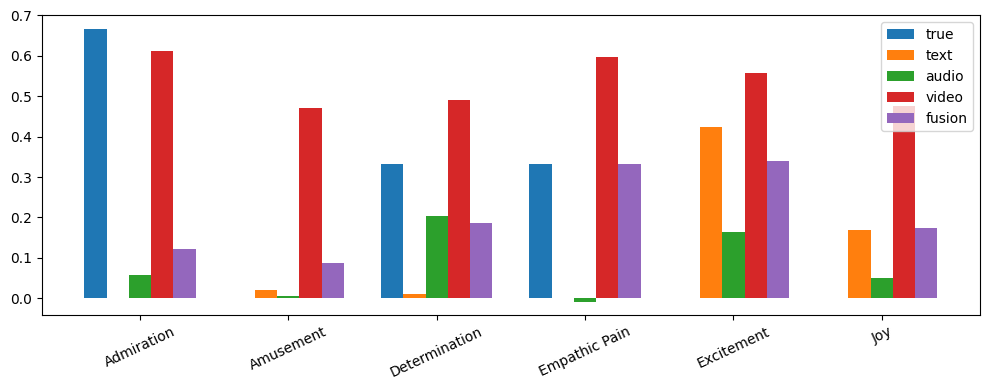

=== 08400 ===
video_path: /home/danila/networks/data/videos/08400.mp4


,emotion,y_true,text,audio,video,fusion
0,Admiration,0.333333,0.042734,0.044852,0.700218,0.167441
1,Amusement,0.333333,-0.005802,0.151525,0.820291,0.227436
2,Determination,0.000000,0.365879,0.271587,0.149035,0.291191
3,Empathic Pain,0.000000,0.004971,-0.015185,0.359217,0.165286
4,Excitement,0.333333,-0.001313,0.276091,0.837898,0.296624
5,Joy,1.000000,-0.003973,0.167915,0.873886,0.265814


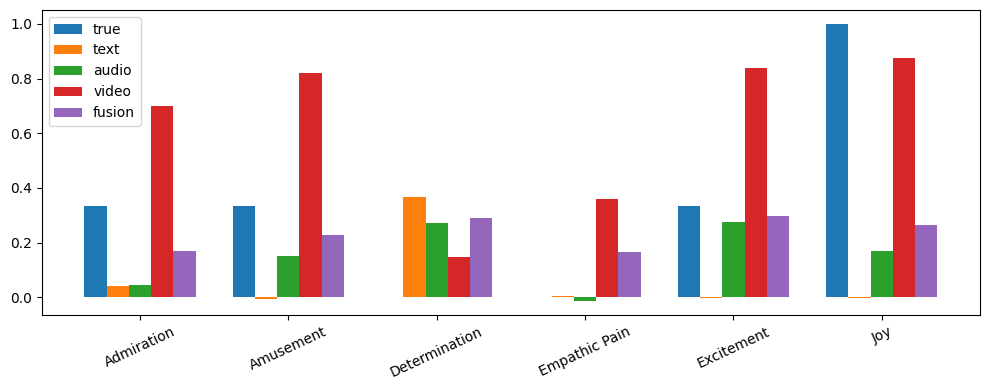

=== 08570 ===
video_path: /home/danila/networks/data/videos/08570.mp4


,emotion,y_true,text,audio,video,fusion
0,Admiration,0.000000,0.369338,0.146068,0.761851,0.367102
1,Amusement,0.333333,0.080875,0.585252,0.844145,0.433775
2,Determination,0.000000,-0.006907,0.049407,0.135399,0.046863
3,Empathic Pain,0.000000,-0.019161,-0.004138,0.277710,0.124130
4,Excitement,0.333333,0.133384,0.249800,0.874600,0.358268
5,Joy,0.333333,-0.019139,0.286295,0.869725,0.306683


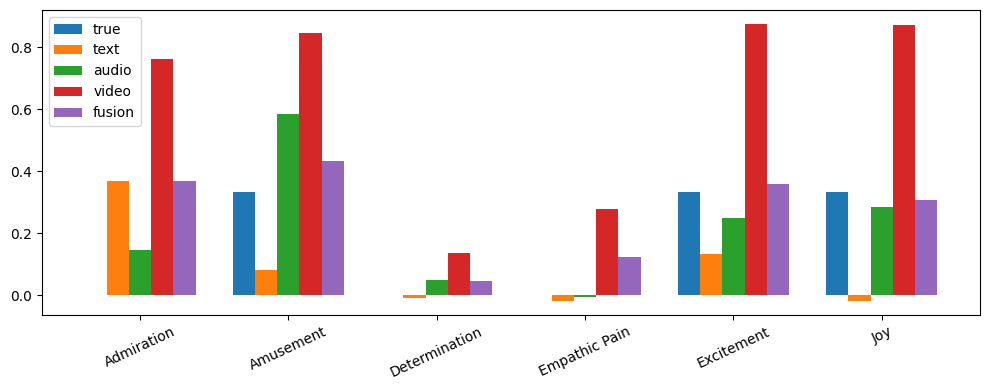

=== 08912 ===
video_path: /home/danila/networks/data/videos/08912.mp4


,emotion,y_true,text,audio,video,fusion
0,Admiration,0.5,0.151168,0.246000,0.738450,0.295513
1,Amusement,0.5,0.023912,0.054260,0.551818,0.135167
2,Determination,0.5,0.042571,0.048291,0.371484,0.116384
3,Empathic Pain,0.0,-0.004652,-0.003184,0.422064,0.210209
4,Excitement,1.0,0.276201,0.519501,0.693506,0.454772
5,Joy,0.5,0.009753,0.281101,0.638789,0.239605


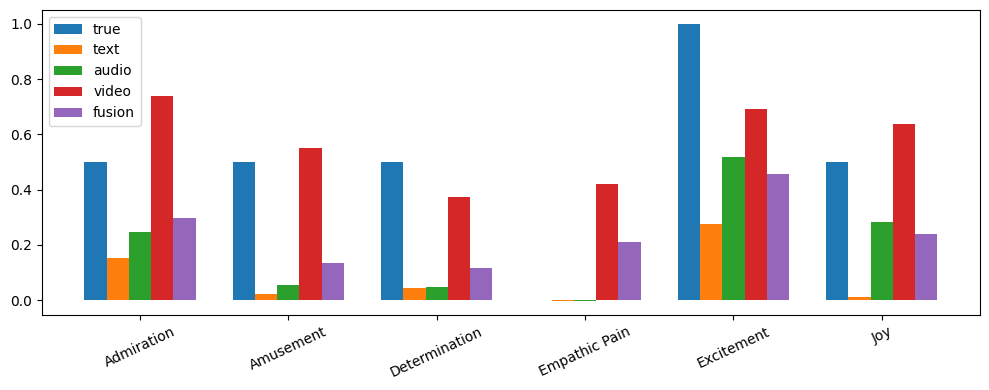

=== 09077 ===
video_path: /home/danila/networks/data/videos/09077.mp4


,emotion,y_true,text,audio,video,fusion
0,Admiration,0.5,0.018055,0.429147,0.568316,0.245895
1,Amusement,0.0,0.085802,-0.027815,0.442442,0.126439
2,Determination,0.0,0.026679,-0.053859,0.473394,0.113565
3,Empathic Pain,0.5,-0.000672,0.470041,0.567612,0.439651
4,Excitement,0.0,0.071394,0.123355,0.517356,0.180443
5,Joy,0.0,0.371520,0.039690,0.493281,0.309864


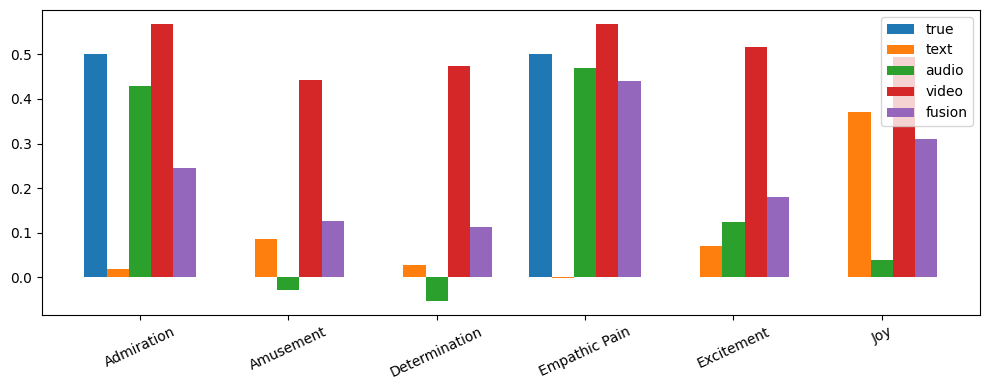

In [14]:
# ===== Visualize a few examples =====
N_SHOW = 5
sel = cand_all.head(N_SHOW)

for _, r in sel.iterrows():
    vid = r["video_id"]
    print("===", vid, "===")
    print("video_path:", r["video_path"])

    yt = np.array([r[f"y_true_{e}"] for e in EMOTIONS], dtype=np.float32)
    p_text = P_text[ids.index(vid)] if vid in ids else None
    p_audio = P_audio[ids.index(vid)] if vid in ids else None
    p_video = P_video[ids.index(vid)] if vid in ids else None
    p_fuse = P_fusion[ids.index(vid)] if vid in ids else None

    tbl = pd.DataFrame({
        "emotion": EMOTIONS,
        "y_true": yt,
        "text": p_text,
        "audio": p_audio,
        "video": p_video,
        "fusion": p_fuse,
    })
    display(tbl)

    # bar chart
    x = np.arange(len(EMOTIONS))
    width = 0.15
    plt.figure(figsize=(10, 4))
    plt.bar(x - 2*width, yt, width, label="true")
    if p_text is not None: plt.bar(x - width, p_text, width, label="text")
    if p_audio is not None: plt.bar(x, p_audio, width, label="audio")
    if p_video is not None: plt.bar(x + width, p_video, width, label="video")
    plt.bar(x + 2*width, p_fuse, width, label="fusion")
    plt.xticks(x, EMOTIONS, rotation=25)
    plt.legend()
    plt.tight_layout()
    plt.show()
